<a href="https://colab.research.google.com/github/Suhasri28/SDC-Activities/blob/main/Supervised_Unsupervised_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Linear Regression

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Sample dataset (you can expand this or replace it with real data)
data = {
    'Area': [1000, 1500, 2000, 2500, 3000],
    'Bedrooms': [2, 3, 3, 4, 4],
    'Bathrooms': [1, 2, 2, 3, 3],
    'Price': [200000, 300000, 400000, 500000, 600000]
}

# Load data into a DataFrame
df = pd.DataFrame(data)

# Features and Target
X = df[['Area', 'Bedrooms', 'Bathrooms']]
y = df['Price']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# ---- Get User Input ----
print("Enter details of the house:")

area = float(input("Area (in sq ft): "))
bedrooms = int(input("Number of Bedrooms: "))
bathrooms = int(input("Number of Bathrooms: "))

# Make prediction
user_input = [[area, bedrooms, bathrooms]]
predicted_price = model.predict(user_input)

print(f"\nEstimated House Price: ${predicted_price[0]:,.2f}")



Enter details of the house:
Area (in sq ft): 1000
Number of Bedrooms: 2
Number of Bathrooms: 2

Estimated House Price: $200,000.00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
Logistic regression

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Sample dataset (features: size in sqft, number of bedrooms, price category)
# Price Category: 1 = Expensive, 0 = Not Expensive
data = [
    [1500, 3, 0],
    [1600, 3, 0],
    [1700, 3, 0],
    [1800, 4, 1],
    [1900, 4, 1],
    [2000, 4, 1],
    [2100, 5, 1],
    [1400, 2, 0],
    [1200, 2, 0]
]

# Split features and labels
X = [row[:2] for row in data]  # Size and bedrooms
y = [row[2] for row in data]  # Price category

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# === USER INPUT ===
size = int(input("Enter the size of the house in sqft: "))
bedrooms = int(input("Enter the number of bedrooms: "))
user_input = np.array([[size, bedrooms]])

# Predict
prediction = model.predict(user_input)
label = "Expensive" if prediction[0] == 1 else "Not Expensive"

print(f"The house is predicted to be: {label}")


Enter the size of the house in sqft: 2500
Enter the number of bedrooms: 4
The house is predicted to be: Expensive


In [ ]:
Random Forest

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Sample dataset (you can replace this with a CSV file or a larger dataset)
data = {
    'Bedrooms': [3, 4, 2, 5, 3],
    'Bathrooms': [2, 3, 1, 4, 2],
    'Area': [1500, 2500, 1200, 3000, 1600],
    'LocationScore': [8, 9, 7, 10, 8],
    'Price': [300000, 500000, 200000, 600000, 320000]
}

df = pd.DataFrame(data)

# Features and Target
X = df[['Bedrooms', 'Bathrooms', 'Area', 'LocationScore']]
y = df['Price']

# Split the dataset (not necessary for prediction, just to simulate training)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get user input
print("Enter house details to predict the price:")
bedrooms = int(input("Number of bedrooms: "))
bathrooms = int(input("Number of bathrooms: "))
area = int(input("Area in square feet: "))
location_score = int(input("Location score (1-10): "))

# Predict price
user_input = pd.DataFrame([[bedrooms, bathrooms, area, location_score]],
                          columns=['Bedrooms', 'Bathrooms', 'Area', 'LocationScore'])
predicted_price = model.predict(user_input)[0]

print(f"\nEstimated House Price: ${predicted_price:,.2f}")


Enter house details to predict the price:
Number of bedrooms: 5
Number of bathrooms: 6
Area in square feet: 3000
Location score (1-10): 8

Estimated House Price: $469,400.00


In [ ]:
Support Vector Machines (SVM)

In [6]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sample dataset
data = {
    'Bedrooms': [3, 4, 2, 5, 3],
    'Bathrooms': [2, 3, 1, 4, 2],
    'Area': [1500, 2500, 1200, 3000, 1600],
    'LocationScore': [8, 9, 7, 10, 8],
    'Price': [300000, 500000, 200000, 600000, 320000]
}

df = pd.DataFrame(data)

# Features and target
X = df[['Bedrooms', 'Bathrooms', 'Area', 'LocationScore']]
y = df['Price']

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Train SVM model
svm_model = SVR(kernel='rbf')
svm_model.fit(X_train, y_train)

# --- User Input ---
print("Enter house details to predict the price:")
bedrooms = int(input("Number of bedrooms: "))
bathrooms = int(input("Number of bathrooms: "))
area = int(input("Area in square feet: "))
location_score = int(input("Location score (1-10): "))

# Prepare input for prediction
user_data = [[bedrooms, bathrooms, area, location_score]]
user_scaled = scaler_X.transform(user_data)

# Predict and inverse scale
predicted_scaled_price = svm_model.predict(user_scaled)
predicted_price = scaler_y.inverse_transform(predicted_scaled_price.reshape(-1, 1))[0][0]

print(f"\nEstimated House Price: ${predicted_price:,.2f}")


Enter house details to predict the price:
Number of bedrooms: 4
Number of bathrooms: 4
Area in square feet: 3000
Location score (1-10): 1

Estimated House Price: $377,691.54


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
K-Nearest Neighbors (KNN)

In [7]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sample dataset
data = {
    'Bedrooms': [3, 4, 2, 5, 3],
    'Bathrooms': [2, 3, 1, 4, 2],
    'Area': [1500, 2500, 1200, 3000, 1600],
    'LocationScore': [8, 9, 7, 10, 8],
    'Price': [300000, 500000, 200000, 600000, 320000]
}

df = pd.DataFrame(data)

# Features and target
X = df[['Bedrooms', 'Bathrooms', 'Area', 'LocationScore']]
y = df['Price']

# Scale features for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# KNN model
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train, y_train)

# --- User Input ---
print("Enter house details to predict the price:")
bedrooms = int(input("Number of bedrooms: "))
bathrooms = int(input("Number of bathrooms: "))
area = int(input("Area in square feet: "))
location_score = int(input("Location score (1-10): "))

# Prepare and scale input
user_input = [[bedrooms, bathrooms, area, location_score]]
user_scaled = scaler.transform(user_input)

# Predict price
predicted_price = knn_model.predict(user_scaled)[0]

print(f"\nEstimated House Price: ${predicted_price:,.2f}")


Enter house details to predict the price:
Number of bedrooms: 4
Number of bathrooms: 4
Area in square feet: 3500
Location score (1-10): 1

Estimated House Price: $273,333.33


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
UNsupervised Algorithm

In [ ]:
K-Means Clustering

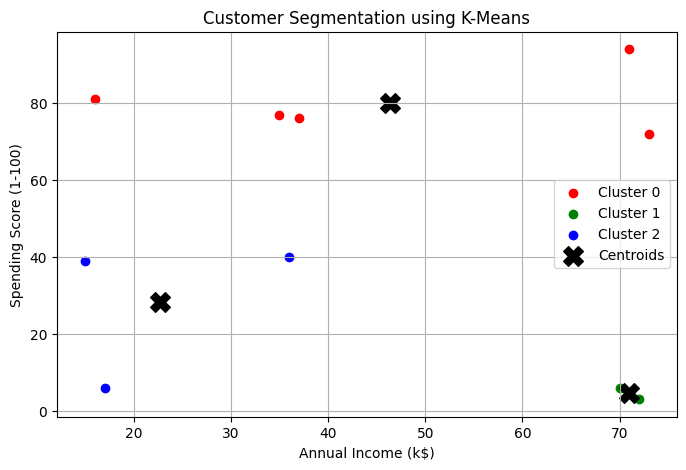

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample data: Annual Income vs Spending Score
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'AnnualIncome': [15, 16, 17, 35, 36, 37, 70, 71, 72, 73],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
}

df = pd.DataFrame(data)

# Features for clustering
X = df[['AnnualIncome', 'SpendingScore']]

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['AnnualIncome'], cluster_data['SpendingScore'],
                color=colors[i], label=f'Cluster {i}')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroids')

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
Hierarchical Clustering

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample data: Annual Income vs Spending Score
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'AnnualIncome': [15, 16, 17, 35, 36, 37, 70, 71, 72, 73],
    'SpendingScore': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
}

df = pd.DataFrame(data)
X = df[['AnnualIncome', 'SpendingScore']]

# Step 1: Create Dendrogram to help choose number of clusters
linked = linkage(X, method='ward')  # 'ward' minimizes variance

plt.figure(figsize=(10, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Customer Dendrogram 🌸")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

# Step 2: Apply Agglomerative Hierarchical Clustering
# Let's say we decide to use 3 clusters from the dendrogram
model = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(X)

# Visualize clusters
plt.figure(figsize=(8, 5))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(df[df['Cluster'] == i]['AnnualIncome'],
                df[df['Cluster'] == i]['SpendingScore'],
                color=colors[i], label=f'Cluster {i}')

plt.title("Hierarchical Clustering of Customers 🌸")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
DBSCAN (Density-Based Spatial Clustering of Applications with Noise)